In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

print("\n" + "=" * 70)
print("VERIFICA AMBIENTE CALIBRAZIONE")
print("=" * 70)

checks = {
    "Cartella progetto": DRIVE_PROJECT,
    "Cartella src": DRIVE_PROJECT / "src",
    "Metadata split": DRIVE_PROJECT / "metadata" / "dataset_splits.csv",

    "Checkpoint Xception robust":
        DRIVE_PROJECT
        / "xception_robust"
        / "models"
        / "xception_robust_best.pth",

    "Checkpoint EfficientNet-B4 robust":
        DRIVE_PROJECT
        / "efficientnet_b4_robust"
        / "models"
        / "efficientnet_b4_robust_best.pth",

    "Dataset runtime":
        Path("/content/data_processed/faces"),
}

for name, path in checks.items():
    print(f"{name:35s}: {path.exists()}")

print("\nDrive project:")
print(DRIVE_PROJECT)

Mounted at /content/drive

VERIFICA AMBIENTE CALIBRAZIONE
Cartella progetto                  : True
Cartella src                       : True
Metadata split                     : True
Checkpoint Xception robust         : True
Checkpoint EfficientNet-B4 robust  : True
Dataset runtime                    : False

Drive project:
/content/drive/MyDrive/deepfake-thesis


In [3]:
from pathlib import Path

DRIVE_PROJECT = Path("/content/drive/MyDrive/deepfake-thesis")

print("=" * 70)
print("RICERCA DATASET SU DRIVE")
print("=" * 70)

# Cerchiamo cartelle faces
face_dirs = [
    p for p in DRIVE_PROJECT.rglob("faces")
    if p.is_dir()
]

print("\nCartelle 'faces' trovate:")
if face_dirs:
    for p in face_dirs:
        print(" -", p)
else:
    print("Nessuna.")

# Cerchiamo archivi possibili
archives = []

for ext in ("*.zip", "*.tar", "*.tar.gz", "*.tgz"):
    archives.extend(DRIVE_PROJECT.rglob(ext))

print("\nArchivi trovati:")
if archives:
    for p in archives:
        print(" -", p)
else:
    print("Nessun archivio trovato.")

# Controllo eventuale data_processed
data_processed = list(DRIVE_PROJECT.rglob("data_processed"))

print("\nCartelle 'data_processed' trovate:")
if data_processed:
    for p in data_processed:
        print(" -", p)
else:
    print("Nessuna.")

RICERCA DATASET SU DRIVE

Cartelle 'faces' trovate:
Nessuna.

Archivi trovati:
 - /content/drive/MyDrive/deepfake-thesis/deepfake_training.zip
 - /content/drive/MyDrive/deepfake-thesis/faces.zip

Cartelle 'data_processed' trovate:
Nessuna.


In [4]:
from pathlib import Path
from google.colab import drive

print("Drive presente:", Path("/content/drive").exists())
print("MyDrive presente:", Path("/content/drive/MyDrive").exists())

if not Path("/content/drive/MyDrive").exists():
    print("\nDrive non montato: lo rimonto...")
    drive.mount("/content/drive")

print("\nDopo il controllo:")
print("MyDrive presente:", Path("/content/drive/MyDrive").exists())

project = Path("/content/drive/MyDrive/deepfake-thesis")

print("deepfake-thesis presente:", project.exists())

Drive presente: True
MyDrive presente: True

Dopo il controllo:
MyDrive presente: True
deepfake-thesis presente: True


In [5]:
from pathlib import Path

project = Path("/content/drive/MyDrive/deepfake-thesis")

print("Contenuto di deepfake-thesis:\n")

for p in sorted(project.iterdir()):
    print(repr(p.name), "| file:", p.is_file(), "| dir:", p.is_dir())

Contenuto di deepfake-thesis:

'deepfake_training.zip' | file: True | dir: False
'efficientnet_b4_baseline' | file: False | dir: True
'efficientnet_b4_robust' | file: False | dir: True
'faces.zip' | file: True | dir: False
'metadata' | file: False | dir: True
'results' | file: False | dir: True
'src' | file: False | dir: True
'xception_baseline' | file: False | dir: True
'xception_robust' | file: False | dir: True


In [6]:
from pathlib import Path
import zipfile

ZIP_PATH = Path("/content/drive/MyDrive/deepfake-thesis/faces.zip")

print("ZIP esiste:", ZIP_PATH.exists())

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()

print("Numero elementi:", len(names))
print("\nPrimi 20 percorsi:\n")

for name in names[:20]:
    print(name)

ZIP esiste: True
Numero elementi: 49654

Primi 20 percorsi:

faces/
faces/Deepfakes_000_003_frame_00.png
faces/Deepfakes_000_003_frame_01.png
faces/Deepfakes_000_003_frame_02.png
faces/Deepfakes_000_003_frame_03.png
faces/Deepfakes_000_003_frame_04.png
faces/Deepfakes_000_003_frame_05.png
faces/Deepfakes_000_003_frame_06.png
faces/Deepfakes_000_003_frame_07.png
faces/Deepfakes_000_003_frame_08.png
faces/Deepfakes_000_003_frame_09.png
faces/Deepfakes_001_870_frame_00.png
faces/Deepfakes_001_870_frame_01.png
faces/Deepfakes_001_870_frame_02.png
faces/Deepfakes_001_870_frame_03.png
faces/Deepfakes_001_870_frame_04.png
faces/Deepfakes_001_870_frame_05.png
faces/Deepfakes_001_870_frame_06.png
faces/Deepfakes_001_870_frame_07.png
faces/Deepfakes_001_870_frame_08.png


In [7]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/deepfake-thesis/faces.zip"
)

EXTRACT_DIR = Path(
    "/content/data_processed"
)

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Estrazione in corso...")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

FACES_DIR = EXTRACT_DIR / "faces"

print("\nEstrazione completata.")
print("Cartella faces esiste:", FACES_DIR.exists())

images = list(FACES_DIR.glob("*.png"))

print("Numero immagini:", len(images))

if images:
    print("Esempio:", images[0])

Estrazione in corso...

Estrazione completata.
Cartella faces esiste: True
Numero immagini: 49653
Esempio: /content/data_processed/faces/Deepfakes_069_961_frame_01.png


In [8]:
from pathlib import Path
import shutil

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

RUNTIME_SRC = Path("/content/src")
RUNTIME_METADATA = Path("/content/metadata")

RUNTIME_SRC.mkdir(
    parents=True,
    exist_ok=True
)

RUNTIME_METADATA.mkdir(
    parents=True,
    exist_ok=True
)

# File necessari
files_to_copy = [
    "dataset.py",
    "models.py",
]

for filename in files_to_copy:

    source = DRIVE_PROJECT / "src" / filename
    destination = RUNTIME_SRC / filename

    if not source.exists():
        raise FileNotFoundError(
            f"File non trovato su Drive: {source}"
        )

    shutil.copy2(
        source,
        destination
    )

    print(
        f"{filename:20s}: copiato"
    )

# Copia metadata
metadata_source = (
    DRIVE_PROJECT
    / "metadata"
    / "dataset_splits.csv"
)

metadata_destination = (
    RUNTIME_METADATA
    / "dataset_splits.csv"
)

shutil.copy2(
    metadata_source,
    metadata_destination
)

print(
    f"{'dataset_splits.csv':20s}: copiato"
)

print("\nControlli finali:")

print(
    "dataset.py:",
    (RUNTIME_SRC / "dataset.py").exists()
)

print(
    "models.py:",
    (RUNTIME_SRC / "models.py").exists()
)

print(
    "metadata:",
    metadata_destination.exists()
)

print(
    "faces:",
    Path("/content/data_processed/faces").exists()
)

dataset.py          : copiato
models.py           : copiato
dataset_splits.csv  : copiato

Controlli finali:
dataset.py: True
models.py: True
metadata: True
faces: True


In [9]:
from pathlib import Path
import pandas as pd

METADATA_FILE = Path(
    "/content/metadata/dataset_splits.csv"
)

FACES_DIR = Path(
    "/content/data_processed/faces"
)

df = pd.read_csv(METADATA_FILE)

val_df = df[df["split"] == "val"].copy()

print("=" * 70)
print("VERIFICA VALIDATION SET")
print("=" * 70)

print("Totale metadata:", len(df))
print("Validation set:", len(val_df))

print("\nDistribuzione classi:")
print(val_df["label"].value_counts().sort_index())

print("\nFilename duplicati:")
print(val_df["filename"].duplicated().sum())

missing = [
    filename
    for filename in val_df["filename"]
    if not (FACES_DIR / filename).exists()
]

print("\nFile mancanti:", len(missing))

if missing:
    print("Primi file mancanti:")
    for name in missing[:10]:
        print("-", name)

print("\nControllo finale:")
print("Validation = 6990:", len(val_df) == 6990)
print("Nessun duplicato:", val_df["filename"].duplicated().sum() == 0)
print("Nessun file mancante:", len(missing) == 0)

VERIFICA VALIDATION SET
Totale metadata: 49653
Validation set: 6990

Distribuzione classi:
label
0    1400
1    5590
Name: count, dtype: int64

Filename duplicati:
0

File mancanti: 0

Controllo finale:
Validation = 6990: True
Nessun duplicato: True
Nessun file mancante: True


In [10]:
from pathlib import Path
import torch

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

checkpoints = {
    "Xception robust":
        DRIVE_PROJECT
        / "xception_robust"
        / "models"
        / "xception_robust_best.pth",

    "EfficientNet-B4 robust":
        DRIVE_PROJECT
        / "efficientnet_b4_robust"
        / "models"
        / "efficientnet_b4_robust_best.pth",
}

print("=" * 70)
print("VERIFICA GPU E CHECKPOINT")
print("=" * 70)

print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

for name, path in checkpoints.items():

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    print("Esiste:", path.exists())
    print("Percorso:", path)

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    print("Tipo oggetto:", type(checkpoint))

    if isinstance(checkpoint, dict):
        print("Chiavi checkpoint:")
        for key in checkpoint.keys():
            print(" -", key)

        # Se contiene direttamente uno state_dict
        tensor_keys = [
            k for k, v in checkpoint.items()
            if torch.is_tensor(v)
        ]

        print(
            "Numero chiavi tensor al livello principale:",
            len(tensor_keys)
        )

VERIFICA GPU E CHECKPOINT
CUDA disponibile: True
GPU: Tesla T4

----------------------------------------------------------------------
Xception robust
----------------------------------------------------------------------
Esiste: True
Percorso: /content/drive/MyDrive/deepfake-thesis/xception_robust/models/xception_robust_best.pth
Tipo oggetto: <class 'dict'>
Chiavi checkpoint:
 - model_name
 - epoch
 - model_state_dict
 - optimizer_state_dict
 - scheduler_state_dict
 - validation_loss
 - class_weights
 - initial_learning_rate
 - weight_decay
 - random_seed
 - num_classes
Numero chiavi tensor al livello principale: 1

----------------------------------------------------------------------
EfficientNet-B4 robust
----------------------------------------------------------------------
Esiste: True
Percorso: /content/drive/MyDrive/deepfake-thesis/efficientnet_b4_robust/models/efficientnet_b4_robust_best.pth
Tipo oggetto: <class 'dict'>
Chiavi checkpoint:
 - model_name
 - epoch
 - model_state_

In [11]:
import sys
import subprocess
import torch
from pathlib import Path

# ------------------------------------------------------------
# 1. Assicuriamoci che timm sia disponibile
# ------------------------------------------------------------

try:
    import timm
    print("timm già installato:", timm.__version__)
except ImportError:
    print("timm non trovato: installazione...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "timm"]
    )
    import timm
    print("timm installato:", timm.__version__)


# ------------------------------------------------------------
# 2. Import dei nostri modelli
# ------------------------------------------------------------

sys.path.insert(0, "/content/src")

from models import create_model


# ------------------------------------------------------------
# 3. Configurazione
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

configs = {
    "xception": {
        "checkpoint":
            DRIVE_PROJECT
            / "xception_robust"
            / "models"
            / "xception_robust_best.pth",
        "input_size": 299,
    },

    "efficientnet_b4": {
        "checkpoint":
            DRIVE_PROJECT
            / "efficientnet_b4_robust"
            / "models"
            / "efficientnet_b4_robust_best.pth",
        "input_size": 380,
    },
}


# ------------------------------------------------------------
# 4. Caricamento modelli robust
# ------------------------------------------------------------

models = {}

print("\n" + "=" * 70)
print("CARICAMENTO MODELLI ROBUST")
print("=" * 70)

for model_name, config in configs.items():

    print("\n" + "-" * 70)
    print(model_name.upper())
    print("-" * 70)

    checkpoint = torch.load(
        config["checkpoint"],
        map_location="cpu",
        weights_only=False
    )

    model = create_model(
        model_name=model_name,
        pretrained=False,
        num_classes=2
    )

    result = model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    model = model.to(DEVICE)
    model.eval()

    models[model_name] = model

    print("Checkpoint model_name:", checkpoint["model_name"])
    print("Epoch salvata:", checkpoint["epoch"])
    print("Validation loss:", checkpoint["validation_loss"])
    print("Numero classi:", checkpoint["num_classes"])

    print("Missing keys:", result.missing_keys)
    print("Unexpected keys:", result.unexpected_keys)

    # Test forward
    size = config["input_size"]

    dummy = torch.randn(
        1, 3, size, size,
        device=DEVICE
    )

    with torch.no_grad():
        output = model(dummy)

    print("Output shape:", tuple(output.shape))


print("\n" + "=" * 70)
print("MODELLI CARICATI CORRETTAMENTE")
print("=" * 70)

print("Device:", DEVICE)
print("Modelli disponibili:", list(models.keys()))

timm già installato: 1.0.29

CARICAMENTO MODELLI ROBUST

----------------------------------------------------------------------
XCEPTION
----------------------------------------------------------------------
Checkpoint model_name: xception
Epoch salvata: 2
Validation loss: 0.14840965710091705
Numero classi: 2
Missing keys: []
Unexpected keys: []
Output shape: (1, 2)

----------------------------------------------------------------------
EFFICIENTNET_B4
----------------------------------------------------------------------
Checkpoint model_name: efficientnet_b4
Epoch salvata: 3
Validation loss: 0.16612674928885582
Numero classi: 2
Missing keys: []
Unexpected keys: []
Output shape: (1, 2)

MODELLI CARICATI CORRETTAMENTE
Device: cuda
Modelli disponibili: ['xception', 'efficientnet_b4']


In [12]:
import sys
import torch
import pandas as pd

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

sys.path.insert(0, "/content/src")

from dataset import FaceForensicsDataset


# ============================================================
# CONFIGURAZIONE
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

FACES_DIR = Path(
    "/content/data_processed/faces"
)

METADATA_FILE = Path(
    "/content/metadata/dataset_splits.csv"
)

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

use_amp = DEVICE.type == "cuda"


# ============================================================
# FUNZIONE DI ESTRAZIONE LOGITS
# ============================================================

def extract_logits(model_name, model):

    print("\n" + "=" * 70)
    print(f"VALIDATION LOGITS - {model_name.upper()}")
    print("=" * 70)

    dataset = FaceForensicsDataset(
        split="val",
        model_name=model_name,
        csv_path=METADATA_FILE,
        faces_dir=FACES_DIR,
    )

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    rows = []

    model.eval()

    with torch.inference_mode():

        for batch in tqdm(
            dataloader,
            desc=model_name
        ):

            images = batch["image"].to(
                DEVICE,
                non_blocking=True
            )

            labels = batch["label"].to(
                DEVICE,
                non_blocking=True
            )

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=use_amp
            ):
                logits = model(images)

            # Da qui in poi salviamo in float32
            logits_float = logits.float()

            probabilities = torch.softmax(
                logits_float,
                dim=1
            )

            predictions = torch.argmax(
                logits_float,
                dim=1
            )

            confidence = torch.max(
                probabilities,
                dim=1
            ).values

            for i in range(len(labels)):

                rows.append({
                    "filename":
                        batch["filename"][i],

                    "label":
                        int(labels[i].item()),

                    "logit_real":
                        float(
                            logits_float[i, 0]
                            .cpu()
                            .item()
                        ),

                    "logit_fake":
                        float(
                            logits_float[i, 1]
                            .cpu()
                            .item()
                        ),

                    "prob_real":
                        float(
                            probabilities[i, 0]
                            .cpu()
                            .item()
                        ),

                    "prob_fake":
                        float(
                            probabilities[i, 1]
                            .cpu()
                            .item()
                        ),

                    "prediction":
                        int(
                            predictions[i]
                            .cpu()
                            .item()
                        ),

                    "confidence":
                        float(
                            confidence[i]
                            .cpu()
                            .item()
                        ),
                })

    df_logits = pd.DataFrame(rows)

    output_file = (
        RESULTS_DIR
        / f"{model_name}_validation_logits.csv"
    )

    df_logits.to_csv(
        output_file,
        index=False
    )

    accuracy = (
        df_logits["prediction"]
        == df_logits["label"]
    ).mean()

    print("\nCampioni:", len(df_logits))
    print("Accuracy validation:", f"{accuracy:.6f}")

    print(
        "REAL:",
        int((df_logits["label"] == 0).sum())
    )

    print(
        "FAKE:",
        int((df_logits["label"] == 1).sum())
    )

    print("File salvato:")
    print(output_file)

    return df_logits


# ============================================================
# XCEPTION
# ============================================================

xception_val = extract_logits(
    "xception",
    models["xception"]
)


# ============================================================
# EFFICIENTNET-B4
# ============================================================

efficientnet_val = extract_logits(
    "efficientnet_b4",
    models["efficientnet_b4"]
)


# ============================================================
# CONTROLLO FINALE
# ============================================================

print("\n" + "=" * 70)
print("CONTROLLO FINALE")
print("=" * 70)

print(
    "Xception = 6990:",
    len(xception_val) == 6990
)

print(
    "EfficientNet-B4 = 6990:",
    len(efficientnet_val) == 6990
)

print(
    "Stessi filename:",
    xception_val["filename"].tolist()
    == efficientnet_val["filename"].tolist()
)


VALIDATION LOGITS - XCEPTION


xception:   0%|          | 0/219 [00:00<?, ?it/s]


Campioni: 6990
Accuracy validation: 0.947496
REAL: 1400
FAKE: 5590
File salvato:
/content/drive/MyDrive/deepfake-thesis/results/calibration/xception_validation_logits.csv

VALIDATION LOGITS - EFFICIENTNET_B4


efficientnet_b4:   0%|          | 0/219 [00:00<?, ?it/s]


Campioni: 6990
Accuracy validation: 0.945494
REAL: 1400
FAKE: 5590
File salvato:
/content/drive/MyDrive/deepfake-thesis/results/calibration/efficientnet_b4_validation_logits.csv

CONTROLLO FINALE
Xception = 6990: True
EfficientNet-B4 = 6990: True
Stessi filename: True


In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from pathlib import Path


# ============================================================
# CONFIGURAZIONE
# ============================================================

N_BINS = 15

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)


# ============================================================
# FUNZIONE ECE
# ============================================================

def compute_ece(
    probabilities,
    labels,
    n_bins=15
):

    confidences, predictions = torch.max(
        probabilities,
        dim=1
    )

    correctness = (
        predictions == labels
    ).float()

    bin_edges = torch.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = torch.tensor(0.0)

    reliability_rows = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences > lower)
                &
                (confidences <= upper)
            )

        count = int(mask.sum().item())

        if count > 0:

            mean_confidence = (
                confidences[mask]
                .mean()
                .item()
            )

            accuracy = (
                correctness[mask]
                .mean()
                .item()
            )

            proportion = (
                count
                / len(labels)
            )

            gap = abs(
                accuracy
                - mean_confidence
            )

            ece += (
                proportion
                * gap
            )

        else:

            mean_confidence = np.nan
            accuracy = np.nan
            gap = np.nan
            proportion = 0.0

        reliability_rows.append({
            "bin": i + 1,
            "lower_bound":
                float(lower),
            "upper_bound":
                float(upper),
            "count":
                count,
            "proportion":
                proportion,
            "mean_confidence":
                mean_confidence,
            "accuracy":
                accuracy,
            "absolute_gap":
                gap,
        })

    reliability_df = pd.DataFrame(
        reliability_rows
    )

    return (
        float(ece.item()),
        reliability_df
    )


# ============================================================
# VALUTAZIONE CALIBRAZIONE
# ============================================================

def evaluate_calibration(
    df,
    model_name
):

    logits = torch.tensor(
        df[
            [
                "logit_real",
                "logit_fake",
            ]
        ].values,
        dtype=torch.float32
    )

    labels = torch.tensor(
        df["label"].values,
        dtype=torch.long
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predictions = torch.argmax(
        probabilities,
        dim=1
    )

    accuracy = (
        predictions == labels
    ).float().mean().item()

    # --------------------------------------------------------
    # NLL
    # --------------------------------------------------------

    nll = F.cross_entropy(
        logits,
        labels
    ).item()

    # --------------------------------------------------------
    # Brier Score binario
    # --------------------------------------------------------
    # Classe positiva = FAKE = 1

    fake_probabilities = (
        probabilities[:, 1]
    )

    brier = torch.mean(
        (
            fake_probabilities
            - labels.float()
        ) ** 2
    ).item()

    # --------------------------------------------------------
    # ECE
    # --------------------------------------------------------

    ece, reliability_df = compute_ece(
        probabilities,
        labels,
        n_bins=N_BINS
    )

    # --------------------------------------------------------
    # Confidence media
    # --------------------------------------------------------

    confidence = torch.max(
        probabilities,
        dim=1
    ).values

    mean_confidence = (
        confidence.mean().item()
    )

    # --------------------------------------------------------
    # Salvataggio reliability bins
    # --------------------------------------------------------

    reliability_file = (
        RESULTS_DIR
        / f"{model_name}_validation_reliability_before.csv"
    )

    reliability_df.to_csv(
        reliability_file,
        index=False
    )

    results = {
        "model": model_name,
        "accuracy": accuracy,
        "mean_confidence": mean_confidence,
        "nll": nll,
        "brier_score": brier,
        "ece_15_bins": ece,
    }

    return results


# ============================================================
# XCEPTION
# ============================================================

xception_metrics = evaluate_calibration(
    xception_val,
    "xception"
)


# ============================================================
# EFFICIENTNET-B4
# ============================================================

efficientnet_metrics = evaluate_calibration(
    efficientnet_val,
    "efficientnet_b4"
)


# ============================================================
# TABELLA FINALE
# ============================================================

calibration_before = pd.DataFrame(
    [
        xception_metrics,
        efficientnet_metrics,
    ]
)

output_file = (
    RESULTS_DIR
    / "validation_calibration_before.csv"
)

calibration_before.to_csv(
    output_file,
    index=False
)

print("=" * 80)
print("CALIBRAZIONE PRIMA DEL TEMPERATURE SCALING")
print("=" * 80)

print(
    calibration_before.to_string(
        index=False
    )
)

print("\nSalvato in:")
print(output_file)

CALIBRAZIONE PRIMA DEL TEMPERATURE SCALING
          model  accuracy  mean_confidence      nll  brier_score  ece_15_bins
       xception  0.947496         0.970673 0.148957     0.041282     0.024829
efficientnet_b4  0.945494         0.966760 0.167141     0.043849     0.023849

Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/validation_calibration_before.csv


In [14]:
import torch
import torch.nn.functional as F
import pandas as pd
from pathlib import Path

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)


# ============================================================
# FUNZIONE TEMPERATURE SCALING
# ============================================================

def fit_temperature(df, model_name):

    logits = torch.tensor(
        df[
            [
                "logit_real",
                "logit_fake",
            ]
        ].values,
        dtype=torch.float64
    )

    labels = torch.tensor(
        df["label"].values,
        dtype=torch.long
    )

    # log(T) viene ottimizzato invece di T direttamente:
    # in questo modo T resta sempre positivo.
    log_temperature = torch.nn.Parameter(
        torch.zeros(
            1,
            dtype=torch.float64
        )
    )

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=100,
        line_search_fn="strong_wolfe"
    )

    nll_before = F.cross_entropy(
        logits,
        labels
    ).item()

    def closure():

        optimizer.zero_grad()

        temperature = torch.exp(
            log_temperature
        )

        scaled_logits = (
            logits
            / temperature
        )

        loss = F.cross_entropy(
            scaled_logits,
            labels
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    temperature = torch.exp(
        log_temperature
    ).item()

    scaled_logits = (
        logits
        / temperature
    )

    nll_after = F.cross_entropy(
        scaled_logits,
        labels
    ).item()

    print("\n" + "=" * 70)
    print(model_name.upper())
    print("=" * 70)

    print(
        "Temperature T:",
        f"{temperature:.6f}"
    )

    print(
        "NLL prima:",
        f"{nll_before:.6f}"
    )

    print(
        "NLL dopo:",
        f"{nll_after:.6f}"
    )

    return {
        "model": model_name,
        "temperature": temperature,
        "validation_nll_before": nll_before,
        "validation_nll_after": nll_after,
    }


# ============================================================
# STIMA XCEPTION
# ============================================================

xception_temperature = fit_temperature(
    xception_val,
    "xception"
)


# ============================================================
# STIMA EFFICIENTNET-B4
# ============================================================

efficientnet_temperature = fit_temperature(
    efficientnet_val,
    "efficientnet_b4"
)


# ============================================================
# SALVATAGGIO
# ============================================================

temperature_results = pd.DataFrame(
    [
        xception_temperature,
        efficientnet_temperature,
    ]
)

output_file = (
    RESULTS_DIR
    / "temperature_scaling_parameters.csv"
)

temperature_results.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("PARAMETRI FINALI")
print("=" * 70)

print(
    temperature_results.to_string(
        index=False
    )
)

print("\nSalvato in:")
print(output_file)


XCEPTION
Temperature T: 1.485930
NLL prima: 0.148957
NLL dopo: 0.134443

EFFICIENTNET_B4
Temperature T: 1.558113
NLL prima: 0.167141
NLL dopo: 0.148898

PARAMETRI FINALI
          model  temperature  validation_nll_before  validation_nll_after
       xception     1.485930               0.148957              0.134443
efficientnet_b4     1.558113               0.167141              0.148898

Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/temperature_scaling_parameters.csv


In [15]:
import torch
import pandas as pd

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dataset import FaceForensicsDataset


# ============================================================
# CONFIGURAZIONE
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

FACES_DIR = Path(
    "/content/data_processed/faces"
)

METADATA_FILE = Path(
    "/content/metadata/dataset_splits.csv"
)

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)

use_amp = DEVICE.type == "cuda"


# ============================================================
# ESTRAZIONE LOGITS TEST SET
# ============================================================

def extract_test_logits(
    model_name,
    model
):

    print("\n" + "=" * 70)
    print(f"TEST LOGITS - {model_name.upper()}")
    print("=" * 70)

    dataset = FaceForensicsDataset(
        split="test",
        model_name=model_name,
        csv_path=METADATA_FILE,
        faces_dir=FACES_DIR,
    )

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    rows = []

    model.eval()

    with torch.inference_mode():

        for batch in tqdm(
            dataloader,
            desc=model_name
        ):

            images = batch["image"].to(
                DEVICE,
                non_blocking=True
            )

            labels = batch["label"].to(
                DEVICE,
                non_blocking=True
            )

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=use_amp
            ):
                logits = model(images)

            logits = logits.float()

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            confidence = torch.max(
                probabilities,
                dim=1
            ).values

            for i in range(len(labels)):

                rows.append({
                    "filename":
                        batch["filename"][i],

                    "label":
                        int(labels[i].item()),

                    "logit_real":
                        float(
                            logits[i, 0]
                            .cpu()
                            .item()
                        ),

                    "logit_fake":
                        float(
                            logits[i, 1]
                            .cpu()
                            .item()
                        ),

                    "prob_real":
                        float(
                            probabilities[i, 0]
                            .cpu()
                            .item()
                        ),

                    "prob_fake":
                        float(
                            probabilities[i, 1]
                            .cpu()
                            .item()
                        ),

                    "prediction":
                        int(
                            predictions[i]
                            .cpu()
                            .item()
                        ),

                    "confidence":
                        float(
                            confidence[i]
                            .cpu()
                            .item()
                        ),
                })

    df = pd.DataFrame(rows)

    output_file = (
        RESULTS_DIR
        / f"{model_name}_test_logits.csv"
    )

    df.to_csv(
        output_file,
        index=False
    )

    accuracy = (
        df["prediction"]
        == df["label"]
    ).mean()

    print("\nCampioni:", len(df))
    print(
        "Accuracy test:",
        f"{accuracy:.6f}"
    )

    print(
        "REAL:",
        int((df["label"] == 0).sum())
    )

    print(
        "FAKE:",
        int((df["label"] == 1).sum())
    )

    print("Salvato in:")
    print(output_file)

    return df


# ============================================================
# XCEPTION
# ============================================================

xception_test = extract_test_logits(
    "xception",
    models["xception"]
)


# ============================================================
# EFFICIENTNET-B4
# ============================================================

efficientnet_test = extract_test_logits(
    "efficientnet_b4",
    models["efficientnet_b4"]
)


# ============================================================
# CONTROLLO FINALE
# ============================================================

print("\n" + "=" * 70)
print("CONTROLLO TEST SET")
print("=" * 70)

print(
    "Xception = 6894:",
    len(xception_test) == 6894
)

print(
    "EfficientNet-B4 = 6894:",
    len(efficientnet_test) == 6894
)

print(
    "Stessi filename:",
    xception_test["filename"].tolist()
    == efficientnet_test["filename"].tolist()
)


TEST LOGITS - XCEPTION


xception:   0%|          | 0/216 [00:20<?, ?it/s]


Campioni: 6894
Accuracy test: 0.941688
REAL: 1384
FAKE: 5510
Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/xception_test_logits.csv

TEST LOGITS - EFFICIENTNET_B4


efficientnet_b4:   0%|          | 0/216 [00:00<?, ?it/s]


Campioni: 6894
Accuracy test: 0.938787
REAL: 1384
FAKE: 5510
Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/efficientnet_b4_test_logits.csv

CONTROLLO TEST SET
Xception = 6894: True
EfficientNet-B4 = 6894: True
Stessi filename: True


In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from pathlib import Path


# ============================================================
# CONFIGURAZIONE
# ============================================================

N_BINS = 15

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)


# ============================================================
# CARICAMENTO TEMPERATURE
# ============================================================

temperature_df = pd.read_csv(
    RESULTS_DIR
    / "temperature_scaling_parameters.csv"
)

temperatures = dict(
    zip(
        temperature_df["model"],
        temperature_df["temperature"]
    )
)

print("Temperature utilizzate:")
for model_name, value in temperatures.items():
    print(
        f"{model_name:20s}: "
        f"{value:.6f}"
    )


# ============================================================
# ECE
# ============================================================

def compute_ece_test(
    probabilities,
    labels,
    n_bins=15
):

    confidences, predictions = torch.max(
        probabilities,
        dim=1
    )

    correctness = (
        predictions == labels
    ).float()

    bin_edges = torch.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0
    rows = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )
        else:
            mask = (
                (confidences > lower)
                &
                (confidences <= upper)
            )

        count = int(
            mask.sum().item()
        )

        if count > 0:

            mean_confidence = (
                confidences[mask]
                .mean()
                .item()
            )

            accuracy = (
                correctness[mask]
                .mean()
                .item()
            )

            proportion = (
                count
                / len(labels)
            )

            gap = abs(
                accuracy
                - mean_confidence
            )

            ece += (
                proportion
                * gap
            )

        else:

            mean_confidence = np.nan
            accuracy = np.nan
            proportion = 0.0
            gap = np.nan

        rows.append({
            "bin": i + 1,
            "lower_bound":
                float(lower),
            "upper_bound":
                float(upper),
            "count":
                count,
            "proportion":
                proportion,
            "mean_confidence":
                mean_confidence,
            "accuracy":
                accuracy,
            "absolute_gap":
                gap,
        })

    return (
        float(ece),
        pd.DataFrame(rows)
    )


# ============================================================
# VALUTAZIONE PRIMA / DOPO
# ============================================================

def evaluate_before_after(
    df,
    model_name,
    temperature
):

    logits = torch.tensor(
        df[
            [
                "logit_real",
                "logit_fake",
            ]
        ].values,
        dtype=torch.float64
    )

    labels = torch.tensor(
        df["label"].values,
        dtype=torch.long
    )

    results = []

    for stage, current_logits in [
        ("before", logits),
        (
            "after",
            logits / float(temperature)
        ),
    ]:

        probabilities = torch.softmax(
            current_logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        confidence = torch.max(
            probabilities,
            dim=1
        ).values

        accuracy = (
            predictions == labels
        ).double().mean().item()

        mean_confidence = (
            confidence.mean().item()
        )

        nll = F.cross_entropy(
            current_logits,
            labels
        ).item()

        fake_probabilities = (
            probabilities[:, 1]
        )

        brier = torch.mean(
            (
                fake_probabilities
                - labels.double()
            ) ** 2
        ).item()

        ece, reliability_df = (
            compute_ece_test(
                probabilities.float(),
                labels,
                n_bins=N_BINS
            )
        )

        reliability_file = (
            RESULTS_DIR
            / (
                f"{model_name}_test_"
                f"reliability_{stage}.csv"
            )
        )

        reliability_df.to_csv(
            reliability_file,
            index=False
        )

        results.append({
            "model":
                model_name,
            "stage":
                stage,
            "temperature":
                (
                    1.0
                    if stage == "before"
                    else float(temperature)
                ),
            "accuracy":
                accuracy,
            "mean_confidence":
                mean_confidence,
            "nll":
                nll,
            "brier_score":
                brier,
            "ece_15_bins":
                ece,
        })

    return results


# ============================================================
# XCEPTION
# ============================================================

xception_results = evaluate_before_after(
    xception_test,
    "xception",
    temperatures["xception"]
)


# ============================================================
# EFFICIENTNET-B4
# ============================================================

efficientnet_results = evaluate_before_after(
    efficientnet_test,
    "efficientnet_b4",
    temperatures["efficientnet_b4"]
)


# ============================================================
# TABELLA COMPLETA
# ============================================================

test_calibration = pd.DataFrame(
    xception_results
    + efficientnet_results
)

output_file = (
    RESULTS_DIR
    / "test_calibration_before_after.csv"
)

test_calibration.to_csv(
    output_file,
    index=False
)


print("\n" + "=" * 100)
print("TEST SET - CALIBRAZIONE PRIMA E DOPO")
print("=" * 100)

print(
    test_calibration.to_string(
        index=False
    )
)


# ============================================================
# CONTROLLO ACCURACY
# ============================================================

print("\n" + "=" * 100)
print("CONTROLLO: L'ACCURACY DEVE RESTARE INVARIATA")
print("=" * 100)

for model_name in [
    "xception",
    "efficientnet_b4"
]:

    temp = test_calibration[
        test_calibration["model"]
        == model_name
    ]

    acc_before = (
        temp[
            temp["stage"] == "before"
        ]["accuracy"].iloc[0]
    )

    acc_after = (
        temp[
            temp["stage"] == "after"
        ]["accuracy"].iloc[0]
    )

    print(
        f"{model_name:20s}: "
        f"{acc_before:.6f} -> "
        f"{acc_after:.6f} | "
        f"uguale = "
        f"{np.isclose(acc_before, acc_after)}"
    )


print("\nSalvato in:")
print(output_file)

Temperature utilizzate:
xception            : 1.485930
efficientnet_b4     : 1.558113

TEST SET - CALIBRAZIONE PRIMA E DOPO
          model  stage  temperature  accuracy  mean_confidence      nll  brier_score  ece_15_bins
       xception before     1.000000  0.941688         0.967922 0.177354     0.046868     0.027609
       xception  after     1.485930  0.941688         0.946261 0.156328     0.045072     0.007856
efficientnet_b4 before     1.000000  0.938787         0.962147 0.169969     0.047409     0.025159
efficientnet_b4  after     1.558113  0.938787         0.935939 0.155334     0.045859     0.005770

CONTROLLO: L'ACCURACY DEVE RESTARE INVARIATA
xception            : 0.941688 -> 0.941688 | uguale = True
efficientnet_b4     : 0.938787 -> 0.938787 | uguale = True

Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/test_calibration_before_after.csv


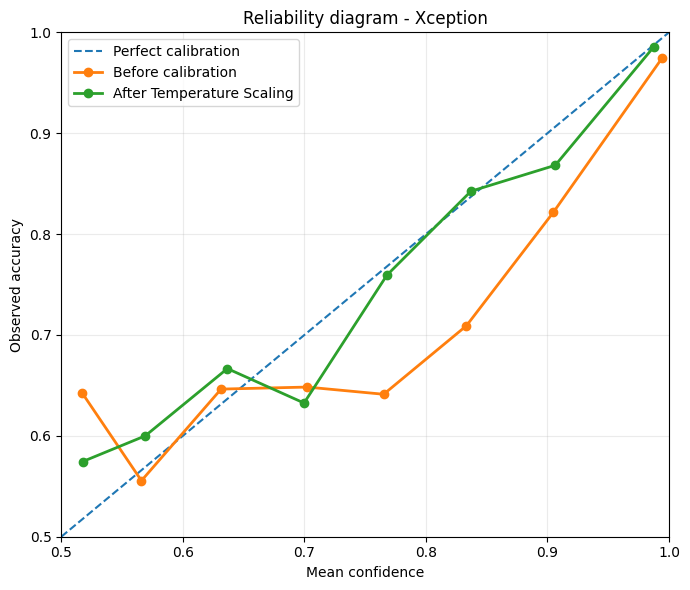

Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/plots/xception_reliability_before_after.png


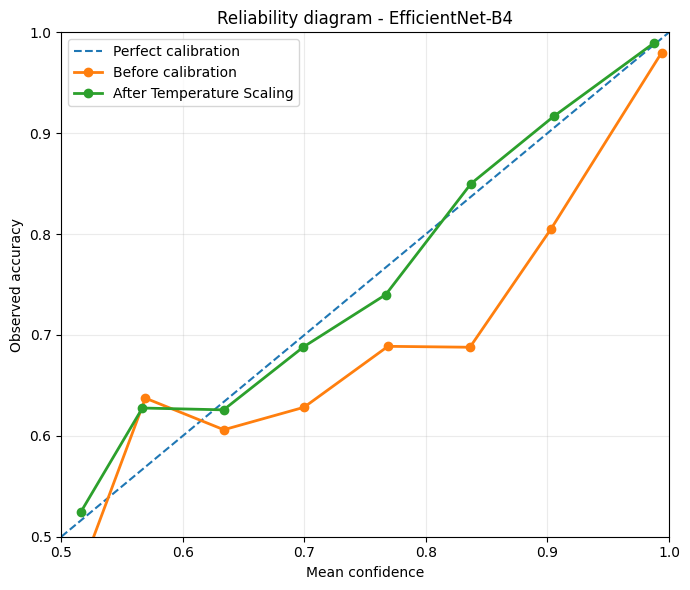

Salvato in:
/content/drive/MyDrive/deepfake-thesis/results/calibration/plots/efficientnet_b4_reliability_before_after.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)

PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def plot_reliability(model_name, display_name):

    before = pd.read_csv(
        RESULTS_DIR
        / f"{model_name}_test_reliability_before.csv"
    )

    after = pd.read_csv(
        RESULTS_DIR
        / f"{model_name}_test_reliability_after.csv"
    )

    # Eliminiamo i bin vuoti
    before = before[
        before["count"] > 0
    ].copy()

    after = after[
        after["count"] > 0
    ].copy()

    plt.figure(figsize=(7, 6))

    # Calibrazione ideale
    plt.plot(
        [0.5, 1.0],
        [0.5, 1.0],
        linestyle="--",
        label="Perfect calibration"
    )

    # Prima
    plt.plot(
        before["mean_confidence"],
        before["accuracy"],
        marker="o",
        linewidth=2,
        label="Before calibration"
    )

    # Dopo
    plt.plot(
        after["mean_confidence"],
        after["accuracy"],
        marker="o",
        linewidth=2,
        label="After Temperature Scaling"
    )

    plt.xlabel("Mean confidence")
    plt.ylabel("Observed accuracy")

    plt.xlim(0.5, 1.0)
    plt.ylim(0.5, 1.0)

    plt.title(
        f"Reliability diagram - {display_name}"
    )

    plt.grid(alpha=0.25)
    plt.legend()

    plt.tight_layout()

    output_file = (
        PLOTS_DIR
        / f"{model_name}_reliability_before_after.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Salvato in:")
    print(output_file)


plot_reliability(
    "xception",
    "Xception"
)

plot_reliability(
    "efficientnet_b4",
    "EfficientNet-B4"
)

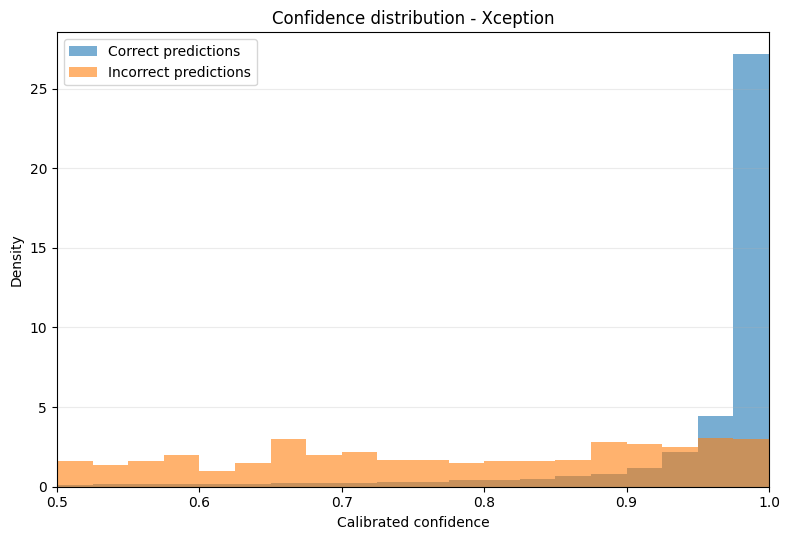


Xception
Predizioni corrette: 6492
Predizioni errate: 402
Confidence media corrette: 0.9567
Confidence media errate: 0.7774
Mediana corrette: 0.9914
Mediana errate: 0.7826

Grafico:
/content/drive/MyDrive/deepfake-thesis/results/calibration/plots/xception_confidence_correct_vs_incorrect.png


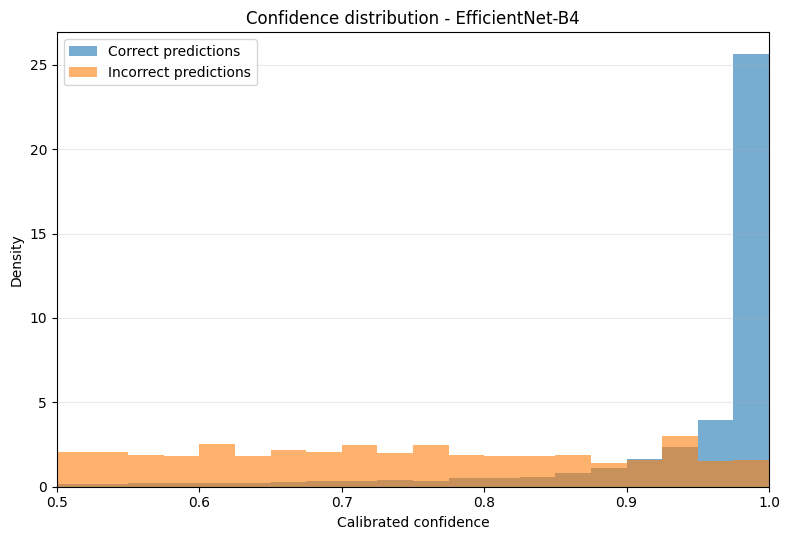


EfficientNet-B4
Predizioni corrette: 6472
Predizioni errate: 422
Confidence media corrette: 0.9485
Confidence media errate: 0.7432
Mediana corrette: 0.9911
Mediana errate: 0.7406

Grafico:
/content/drive/MyDrive/deepfake-thesis/results/calibration/plots/efficientnet_b4_confidence_correct_vs_incorrect.png

RIEPILOGO
          model  correct_count  wrong_count  correct_mean_confidence  wrong_mean_confidence  correct_median_confidence  wrong_median_confidence
       xception           6492          402                 0.956719               0.777377                    0.99138                  0.78263
efficientnet_b4           6472          422                 0.948508               0.743173                    0.99111                  0.74062


In [18]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path


# ============================================================
# CONFIGURAZIONE
# ============================================================

RESULTS_DIR = (
    Path("/content/drive/MyDrive/deepfake-thesis")
    / "results"
    / "calibration"
)

PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# FUNZIONE
# ============================================================

def analyze_confidence_distribution(
    df,
    model_name,
    display_name,
    temperature
):

    logits = torch.tensor(
        df[
            [
                "logit_real",
                "logit_fake"
            ]
        ].values,
        dtype=torch.float64
    )

    labels = torch.tensor(
        df["label"].values,
        dtype=torch.long
    )

    # Temperature Scaling
    calibrated_logits = (
        logits / float(temperature)
    )

    probabilities = torch.softmax(
        calibrated_logits,
        dim=1
    )

    confidence, predictions = torch.max(
        probabilities,
        dim=1
    )

    correct = (
        predictions == labels
    )

    # --------------------------------------------------------
    # DataFrame campione per campione
    # --------------------------------------------------------

    calibrated_df = df.copy()

    calibrated_df[
        "calibrated_prob_real"
    ] = (
        probabilities[:, 0]
        .cpu()
        .numpy()
    )

    calibrated_df[
        "calibrated_prob_fake"
    ] = (
        probabilities[:, 1]
        .cpu()
        .numpy()
    )

    calibrated_df[
        "calibrated_prediction"
    ] = (
        predictions
        .cpu()
        .numpy()
    )

    calibrated_df[
        "calibrated_confidence"
    ] = (
        confidence
        .cpu()
        .numpy()
    )

    calibrated_df[
        "correct"
    ] = (
        correct
        .cpu()
        .numpy()
    )

    # Salvataggio
    output_csv = (
        RESULTS_DIR
        / f"{model_name}_test_calibrated_predictions.csv"
    )

    calibrated_df.to_csv(
        output_csv,
        index=False
    )

    # --------------------------------------------------------
    # Separazione corrette / errate
    # --------------------------------------------------------

    correct_confidence = (
        calibrated_df.loc[
            calibrated_df["correct"],
            "calibrated_confidence"
        ]
    )

    wrong_confidence = (
        calibrated_df.loc[
            ~calibrated_df["correct"],
            "calibrated_confidence"
        ]
    )

    # --------------------------------------------------------
    # Statistiche
    # --------------------------------------------------------

    summary = {
        "model": model_name,

        "correct_count":
            len(correct_confidence),

        "wrong_count":
            len(wrong_confidence),

        "correct_mean_confidence":
            correct_confidence.mean(),

        "wrong_mean_confidence":
            wrong_confidence.mean(),

        "correct_median_confidence":
            correct_confidence.median(),

        "wrong_median_confidence":
            wrong_confidence.median(),
    }

    # --------------------------------------------------------
    # Grafico
    # --------------------------------------------------------

    bins = np.linspace(
        0.5,
        1.0,
        21
    )

    plt.figure(
        figsize=(8, 5.5)
    )

    plt.hist(
        correct_confidence,
        bins=bins,
        density=True,
        alpha=0.6,
        label="Correct predictions"
    )

    plt.hist(
        wrong_confidence,
        bins=bins,
        density=True,
        alpha=0.6,
        label="Incorrect predictions"
    )

    plt.xlabel(
        "Calibrated confidence"
    )

    plt.ylabel(
        "Density"
    )

    plt.title(
        f"Confidence distribution - {display_name}"
    )

    plt.xlim(
        0.5,
        1.0
    )

    plt.legend()
    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    output_plot = (
        PLOTS_DIR
        / (
            f"{model_name}_"
            f"confidence_correct_vs_incorrect.png"
        )
    )

    plt.savefig(
        output_plot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("\n" + "=" * 70)
    print(display_name)
    print("=" * 70)

    print(
        "Predizioni corrette:",
        len(correct_confidence)
    )

    print(
        "Predizioni errate:",
        len(wrong_confidence)
    )

    print(
        "Confidence media corrette:",
        f"{correct_confidence.mean():.4f}"
    )

    print(
        "Confidence media errate:",
        f"{wrong_confidence.mean():.4f}"
    )

    print(
        "Mediana corrette:",
        f"{correct_confidence.median():.4f}"
    )

    print(
        "Mediana errate:",
        f"{wrong_confidence.median():.4f}"
    )

    print("\nGrafico:")
    print(output_plot)

    return summary


# ============================================================
# XCEPTION
# ============================================================

xception_conf_summary = (
    analyze_confidence_distribution(
        xception_test,
        "xception",
        "Xception",
        temperatures["xception"]
    )
)


# ============================================================
# EFFICIENTNET-B4
# ============================================================

efficientnet_conf_summary = (
    analyze_confidence_distribution(
        efficientnet_test,
        "efficientnet_b4",
        "EfficientNet-B4",
        temperatures["efficientnet_b4"]
    )
)


# ============================================================
# TABELLA RIASSUNTIVA
# ============================================================

confidence_summary = pd.DataFrame(
    [
        xception_conf_summary,
        efficientnet_conf_summary
    ]
)

confidence_summary.to_csv(
    RESULTS_DIR
    / "confidence_correct_vs_incorrect_summary.csv",
    index=False
)

print("\n" + "=" * 90)
print("RIEPILOGO")
print("=" * 90)

print(
    confidence_summary.to_string(
        index=False
    )
)

# Selective classification – threshold selection

In [19]:
# ============================================================
# SELECTIVE CLASSIFICATION - SETUP
# ============================================================

from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. MONTA DRIVE SOLO SE NECESSARIO
# ------------------------------------------------------------

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")
else:
    print("Google Drive già montato.")


# ------------------------------------------------------------
# 2. PERCORSI
# ------------------------------------------------------------

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

CALIBRATION_DIR = (
    DRIVE_PROJECT
    / "results"
    / "calibration"
)

SELECTIVE_DIR = (
    DRIVE_PROJECT
    / "results"
    / "selective_classification"
)

SELECTIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. FILE PRODOTTI NEL NOTEBOOK DI CALIBRAZIONE
# ------------------------------------------------------------

XCEPTION_VAL_FILE = (
    CALIBRATION_DIR
    / "xception_validation_logits.csv"
)

EFFICIENTNET_VAL_FILE = (
    CALIBRATION_DIR
    / "efficientnet_b4_validation_logits.csv"
)

TEMPERATURE_FILE = (
    CALIBRATION_DIR
    / "temperature_scaling_parameters.csv"
)


# ------------------------------------------------------------
# 4. CONTROLLO ESISTENZA
# ------------------------------------------------------------

files_to_check = {
    "Xception validation logits":
        XCEPTION_VAL_FILE,

    "EfficientNet-B4 validation logits":
        EFFICIENTNET_VAL_FILE,

    "Temperature Scaling parameters":
        TEMPERATURE_FILE,
}

print("=" * 70)
print("CONTROLLO FILE")
print("=" * 70)

for name, path in files_to_check.items():

    print(
        f"{name:35s}: "
        f"{path.exists()}"
    )

    if not path.exists():
        raise FileNotFoundError(
            f"File non trovato: {path}"
        )


# ------------------------------------------------------------
# 5. CARICAMENTO
# ------------------------------------------------------------

xception_val_sc = pd.read_csv(
    XCEPTION_VAL_FILE
)

efficientnet_val_sc = pd.read_csv(
    EFFICIENTNET_VAL_FILE
)

temperature_df_sc = pd.read_csv(
    TEMPERATURE_FILE
)


# ------------------------------------------------------------
# 6. TEMPERATURE
# ------------------------------------------------------------

temperatures_sc = dict(
    zip(
        temperature_df_sc["model"],
        temperature_df_sc["temperature"]
    )
)

T_XCEPTION = float(
    temperatures_sc["xception"]
)

T_EFFICIENTNET = float(
    temperatures_sc["efficientnet_b4"]
)


# ------------------------------------------------------------
# 7. CONTROLLI
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION SET")
print("=" * 70)

print(
    "Xception:",
    len(xception_val_sc),
    "campioni"
)

print(
    "EfficientNet-B4:",
    len(efficientnet_val_sc),
    "campioni"
)

print(
    "\nXception = 6990:",
    len(xception_val_sc) == 6990
)

print(
    "EfficientNet-B4 = 6990:",
    len(efficientnet_val_sc) == 6990
)

print(
    "Stessi filename:",
    xception_val_sc["filename"].tolist()
    == efficientnet_val_sc["filename"].tolist()
)

print("\nTemperature Scaling:")

print(
    "Xception:",
    f"{T_XCEPTION:.6f}"
)

print(
    "EfficientNet-B4:",
    f"{T_EFFICIENTNET:.6f}"
)

print("\nDirectory risultati selective classification:")
print(SELECTIVE_DIR)

Google Drive già montato.
CONTROLLO FILE
Xception validation logits         : True
EfficientNet-B4 validation logits  : True
Temperature Scaling parameters     : True

VALIDATION SET
Xception: 6990 campioni
EfficientNet-B4: 6990 campioni

Xception = 6990: True
EfficientNet-B4 = 6990: True
Stessi filename: True

Temperature Scaling:
Xception: 1.485930
EfficientNet-B4: 1.558113

Directory risultati selective classification:
/content/drive/MyDrive/deepfake-thesis/results/selective_classification


In [20]:
# ============================================================
# CALCOLO DELLE CONFIDENCE CALIBRATE - VALIDATION SET
# ============================================================

def add_calibrated_confidence(df, temperature):

    df = df.copy()

    # Individua automaticamente i nomi delle colonne dei logits
    possible_logit_pairs = [
        ("logit_real", "logit_fake"),
        ("real_logit", "fake_logit"),
        ("logit_0", "logit_1"),
    ]

    logit_cols = None

    for pair in possible_logit_pairs:
        if pair[0] in df.columns and pair[1] in df.columns:
            logit_cols = pair
            break

    if logit_cols is None:
        raise ValueError(
            "Non trovo le colonne dei logits.\n"
            f"Colonne disponibili: {df.columns.tolist()}"
        )

    # Logits originali
    logits = df[list(logit_cols)].to_numpy(dtype=np.float64)

    # Temperature Scaling
    scaled_logits = logits / temperature

    # Softmax numericamente stabile
    scaled_logits = (
        scaled_logits
        - scaled_logits.max(axis=1, keepdims=True)
    )

    exp_logits = np.exp(scaled_logits)

    probabilities = (
        exp_logits
        / exp_logits.sum(axis=1, keepdims=True)
    )

    # Probabilità calibrate
    df["p_real_cal"] = probabilities[:, 0]
    df["p_fake_cal"] = probabilities[:, 1]

    # Classe predetta dopo calibrazione
    df["pred_cal"] = np.argmax(
        probabilities,
        axis=1
    )

    # Confidence calibrata
    df["confidence_cal"] = np.max(
        probabilities,
        axis=1
    )

    # Se presente, individua la colonna con l'etichetta reale
    possible_label_cols = [
        "label",
        "true_label",
        "y_true"
    ]

    label_col = None

    for col in possible_label_cols:
        if col in df.columns:
            label_col = col
            break

    if label_col is not None:
        df["correct_cal"] = (
            df["pred_cal"].astype(int)
            == df[label_col].astype(int)
        )

    return df, logit_cols, label_col


# ------------------------------------------------------------
# XCEPTION
# ------------------------------------------------------------

xception_val_sc, x_logit_cols, x_label_col = (
    add_calibrated_confidence(
        xception_val_sc,
        T_XCEPTION
    )
)


# ------------------------------------------------------------
# EFFICIENTNET-B4
# ------------------------------------------------------------

efficientnet_val_sc, e_logit_cols, e_label_col = (
    add_calibrated_confidence(
        efficientnet_val_sc,
        T_EFFICIENTNET
    )
)


# ------------------------------------------------------------
# CONTROLLI
# ------------------------------------------------------------

print("=" * 70)
print("CONFIDENCE CALIBRATE - VALIDATION SET")
print("=" * 70)

print("\nXception")
print("Logit columns:", x_logit_cols)
print("Label column:", x_label_col)
print(
    "Confidence min/max:",
    f"{xception_val_sc['confidence_cal'].min():.6f}",
    "/",
    f"{xception_val_sc['confidence_cal'].max():.6f}"
)
print(
    "Confidence media:",
    f"{xception_val_sc['confidence_cal'].mean():.6f}"
)

if x_label_col is not None:
    print(
        "Accuracy:",
        f"{xception_val_sc['correct_cal'].mean():.6f}"
    )


print("\nEfficientNet-B4")
print("Logit columns:", e_logit_cols)
print("Label column:", e_label_col)
print(
    "Confidence min/max:",
    f"{efficientnet_val_sc['confidence_cal'].min():.6f}",
    "/",
    f"{efficientnet_val_sc['confidence_cal'].max():.6f}"
)
print(
    "Confidence media:",
    f"{efficientnet_val_sc['confidence_cal'].mean():.6f}"
)

if e_label_col is not None:
    print(
        "Accuracy:",
        f"{efficientnet_val_sc['correct_cal'].mean():.6f}"
    )


# ------------------------------------------------------------
# VERIFICA MATEMATICA DEL RANGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICA RANGE [0.5, 1.0]")
print("=" * 70)

print(
    "Xception:",
    bool(
        xception_val_sc["confidence_cal"]
        .between(0.5, 1.0)
        .all()
    )
)

print(
    "EfficientNet-B4:",
    bool(
        efficientnet_val_sc["confidence_cal"]
        .between(0.5, 1.0)
        .all()
    )
)

CONFIDENCE CALIBRATE - VALIDATION SET

Xception
Logit columns: ('logit_real', 'logit_fake')
Label column: label
Confidence min/max: 0.500026 / 0.999999
Confidence media: 0.950448
Accuracy: 0.947496

EfficientNet-B4
Logit columns: ('logit_real', 'logit_fake')
Label column: label
Confidence min/max: 0.500801 / 1.000000
Confidence media: 0.942675
Accuracy: 0.945494

VERIFICA RANGE [0.5, 1.0]
Xception: True
EfficientNet-B4: True


SELECTIVE CLASSIFICATION - VALIDATION SET

Xception
Numero soglie candidate: 4155
Soglia iniziale: 0.500000
Coverage alla soglia iniziale: 1.000000
Selective risk alla soglia iniziale: 0.052504
Selective accuracy alla soglia iniziale: 0.947496
Soglia osservata massima: 0.999999

EfficientNet-B4
Numero soglie candidate: 4532
Soglia iniziale: 0.500000
Coverage alla soglia iniziale: 1.000000
Selective risk alla soglia iniziale: 0.054506
Selective accuracy alla soglia iniziale: 0.945494
Soglia osservata massima: 1.000000

File salvati:
/content/drive/MyDrive/deepfake-thesis/results/selective_classification/xception_validation_selective_curve.csv
/content/drive/MyDrive/deepfake-thesis/results/selective_classification/efficientnet_b4_validation_selective_curve.csv


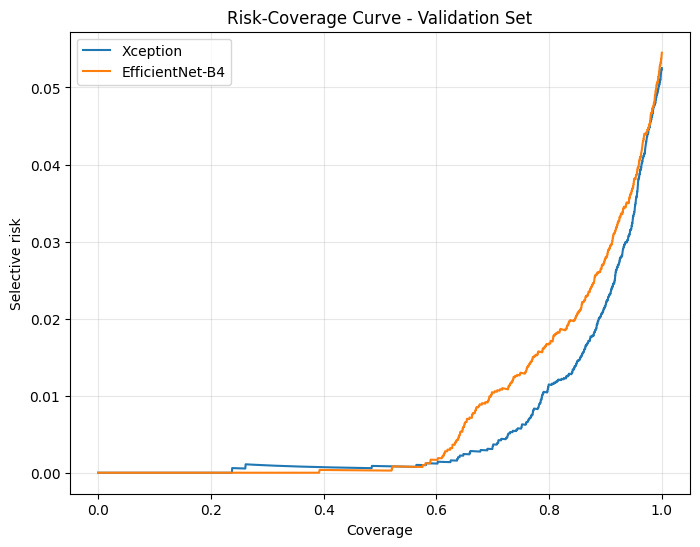

In [21]:
# ============================================================
# SELECTIVE CLASSIFICATION
# COSTRUZIONE DELLE CURVE RISK-COVERAGE SUL VALIDATION SET
# ============================================================

def build_selective_curve(df, model_name):

    confidence = df["confidence_cal"].to_numpy(dtype=np.float64)
    correct = df["correct_cal"].to_numpy(dtype=bool)

    n_total = len(df)

    # --------------------------------------------------------
    # SOGLIE CANDIDATE
    # --------------------------------------------------------
    # Tutte le confidence realmente osservate sul validation set.
    # Aggiungiamo 0.5, limite teorico inferiore della confidence
    # binaria, per rappresentare il caso "nessuna astensione".
    # --------------------------------------------------------

    thresholds = np.unique(
        np.concatenate([
            np.array([0.5]),
            confidence
        ])
    )

    rows = []

    for tau in thresholds:

        accepted_mask = confidence >= tau

        n_accepted = int(accepted_mask.sum())
        n_abstained = n_total - n_accepted

        coverage = n_accepted / n_total
        abstention_rate = n_abstained / n_total

        if n_accepted > 0:

            n_correct = int(
                correct[accepted_mask].sum()
            )

            n_errors = n_accepted - n_correct

            selective_accuracy = (
                n_correct / n_accepted
            )

            selective_risk = (
                n_errors / n_accepted
            )

        else:
            n_correct = 0
            n_errors = 0
            selective_accuracy = np.nan
            selective_risk = np.nan

        rows.append({
            "model": model_name,
            "threshold": tau,
            "n_total": n_total,
            "n_accepted": n_accepted,
            "n_abstained": n_abstained,
            "coverage": coverage,
            "abstention_rate": abstention_rate,
            "n_correct_accepted": n_correct,
            "n_errors_accepted": n_errors,
            "selective_accuracy": selective_accuracy,
            "selective_risk": selective_risk
        })

    curve = pd.DataFrame(rows)

    return curve


# ------------------------------------------------------------
# XCEPTION
# ------------------------------------------------------------

xception_curve_sc = build_selective_curve(
    xception_val_sc,
    "Xception"
)


# ------------------------------------------------------------
# EFFICIENTNET-B4
# ------------------------------------------------------------

efficientnet_curve_sc = build_selective_curve(
    efficientnet_val_sc,
    "EfficientNet-B4"
)


# ------------------------------------------------------------
# SALVATAGGIO
# ------------------------------------------------------------

xception_curve_path = (
    SELECTIVE_DIR
    / "xception_validation_selective_curve.csv"
)

efficientnet_curve_path = (
    SELECTIVE_DIR
    / "efficientnet_b4_validation_selective_curve.csv"
)

xception_curve_sc.to_csv(
    xception_curve_path,
    index=False
)

efficientnet_curve_sc.to_csv(
    efficientnet_curve_path,
    index=False
)


# ------------------------------------------------------------
# CONTROLLI
# ------------------------------------------------------------

print("=" * 70)
print("SELECTIVE CLASSIFICATION - VALIDATION SET")
print("=" * 70)

for name, curve in [
    ("Xception", xception_curve_sc),
    ("EfficientNet-B4", efficientnet_curve_sc)
]:

    first = curve.iloc[0]

    print(f"\n{name}")

    print(
        "Numero soglie candidate:",
        len(curve)
    )

    print(
        "Soglia iniziale:",
        f"{first['threshold']:.6f}"
    )

    print(
        "Coverage alla soglia iniziale:",
        f"{first['coverage']:.6f}"
    )

    print(
        "Selective risk alla soglia iniziale:",
        f"{first['selective_risk']:.6f}"
    )

    print(
        "Selective accuracy alla soglia iniziale:",
        f"{first['selective_accuracy']:.6f}"
    )

    print(
        "Soglia osservata massima:",
        f"{curve['threshold'].max():.6f}"
    )


print("\nFile salvati:")
print(xception_curve_path)
print(efficientnet_curve_path)


# ------------------------------------------------------------
# RISK-COVERAGE CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    xception_curve_sc["coverage"],
    xception_curve_sc["selective_risk"],
    label="Xception"
)

plt.plot(
    efficientnet_curve_sc["coverage"],
    efficientnet_curve_sc["selective_risk"],
    label="EfficientNet-B4"
)

plt.xlabel("Coverage")
plt.ylabel("Selective risk")
plt.title("Risk-Coverage Curve - Validation Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [22]:
# ============================================================
# ANALISI DI POSSIBILI OPERATING POINTS
# Validation set - nessuna soglia scelta ancora
# ============================================================

risk_targets = [
    0.005,   # 0.5%
    0.010,   # 1%
    0.020,   # 2%
    0.030    # 3%
]


def operating_points_by_risk(curve, model_name):

    rows = []

    valid_curve = curve.dropna(
        subset=["selective_risk"]
    ).copy()

    for target_risk in risk_targets:

        # Tutti i punti che rispettano il limite di rischio
        feasible = valid_curve[
            valid_curve["selective_risk"] <= target_risk
        ]

        if len(feasible) == 0:
            rows.append({
                "model": model_name,
                "target_risk": target_risk,
                "threshold": np.nan,
                "coverage": np.nan,
                "abstention_rate": np.nan,
                "selective_risk": np.nan,
                "selective_accuracy": np.nan,
                "n_accepted": np.nan,
                "n_abstained": np.nan
            })

            continue

        # Tra i punti che rispettano il rischio:
        # scegliamo quello con MASSIMA COVERAGE
        best = feasible.loc[
            feasible["coverage"].idxmax()
        ]

        rows.append({
            "model": model_name,
            "target_risk": target_risk,
            "threshold": best["threshold"],
            "coverage": best["coverage"],
            "abstention_rate": best["abstention_rate"],
            "selective_risk": best["selective_risk"],
            "selective_accuracy": best["selective_accuracy"],
            "n_accepted": int(best["n_accepted"]),
            "n_abstained": int(best["n_abstained"])
        })

    return pd.DataFrame(rows)


xception_operating_points = operating_points_by_risk(
    xception_curve_sc,
    "Xception"
)

efficientnet_operating_points = operating_points_by_risk(
    efficientnet_curve_sc,
    "EfficientNet-B4"
)

operating_points = pd.concat(
    [
        xception_operating_points,
        efficientnet_operating_points
    ],
    ignore_index=True
)


# Percentuali leggibili
display_df = operating_points.copy()

display_df["target_risk"] *= 100
display_df["coverage"] *= 100
display_df["abstention_rate"] *= 100
display_df["selective_risk"] *= 100
display_df["selective_accuracy"] *= 100


display_df = display_df.rename(
    columns={
        "target_risk": "Target risk (%)",
        "threshold": "Threshold τ",
        "coverage": "Coverage (%)",
        "abstention_rate": "Abstention (%)",
        "selective_risk": "Observed risk (%)",
        "selective_accuracy": "Selective accuracy (%)",
        "n_accepted": "Accepted",
        "n_abstained": "Abstained"
    }
)

pd.set_option(
    "display.max_columns",
    None
)

print(display_df.round({
    "Target risk (%)": 2,
    "Threshold τ": 6,
    "Coverage (%)": 2,
    "Abstention (%)": 2,
    "Observed risk (%)": 3,
    "Selective accuracy (%)": 3
}).to_string(index=False))

          model  Target risk (%)  Threshold τ  Coverage (%)  Abstention (%)  Observed risk (%)  Selective accuracy (%)  Accepted  Abstained
       Xception              0.5     0.963717         72.75           27.25              0.492                  99.508      5085       1905
       Xception              1.0     0.944960         78.78           21.22              0.999                  99.001      5507       1483
       Xception              2.0     0.862503         88.84           11.16              1.997                  98.003      6210        780
       Xception              3.0     0.744459         93.79            6.21              2.990                  97.010      6556        434
EfficientNet-B4              0.5     0.971596         64.18           35.82              0.490                  99.510      4486       2504
EfficientNet-B4              1.0     0.960607         69.63           30.37              0.986                  99.014      4867       2123
EfficientNet-B4     

In [23]:
# ============================================================
# 2.9.3 - FINAL EVALUATION ON TEST SET
# Fixed thresholds selected on validation set
# ============================================================

# ------------------------------------------------------------
# 1. SOGLIE CONGELATE
# ------------------------------------------------------------

TAU_XCEPTION = 0.862503
TAU_EFFICIENTNET = 0.879208

print("Fixed thresholds:")
print(f"Xception       : {TAU_XCEPTION:.6f}")
print(f"EfficientNet-B4: {TAU_EFFICIENTNET:.6f}")


# ------------------------------------------------------------
# 2. CARICAMENTO LOGITS DEL TEST SET
# ------------------------------------------------------------

XCEPTION_TEST_FILE = (
    CALIBRATION_DIR
    / "xception_test_logits.csv"
)

EFFICIENTNET_TEST_FILE = (
    CALIBRATION_DIR
    / "efficientnet_b4_test_logits.csv"
)

print("\nFile disponibili:")
print("Xception:", XCEPTION_TEST_FILE.exists())
print("EfficientNet-B4:", EFFICIENTNET_TEST_FILE.exists())

if not XCEPTION_TEST_FILE.exists():
    raise FileNotFoundError(XCEPTION_TEST_FILE)

if not EFFICIENTNET_TEST_FILE.exists():
    raise FileNotFoundError(EFFICIENTNET_TEST_FILE)


xception_test_sc = pd.read_csv(
    XCEPTION_TEST_FILE
)

efficientnet_test_sc = pd.read_csv(
    EFFICIENTNET_TEST_FILE
)


print("\nNumero campioni:")
print("Xception:", len(xception_test_sc))
print("EfficientNet-B4:", len(efficientnet_test_sc))

print(
    "Stessi filename:",
    xception_test_sc["filename"].tolist()
    == efficientnet_test_sc["filename"].tolist()
)


# ------------------------------------------------------------
# 3. APPLICA TEMPERATURE SCALING
# ------------------------------------------------------------

xception_test_sc, _, x_test_label_col = (
    add_calibrated_confidence(
        xception_test_sc,
        T_XCEPTION
    )
)

efficientnet_test_sc, _, e_test_label_col = (
    add_calibrated_confidence(
        efficientnet_test_sc,
        T_EFFICIENTNET
    )
)


# ------------------------------------------------------------
# 4. VALUTAZIONE SELECTIVE CLASSIFICATION
# ------------------------------------------------------------

def evaluate_fixed_threshold(
    df,
    threshold,
    model_name,
    label_col
):

    accepted = (
        df["confidence_cal"] >= threshold
    )

    abstained = ~accepted

    n_total = len(df)
    n_accepted = int(accepted.sum())
    n_abstained = int(abstained.sum())

    coverage = n_accepted / n_total
    abstention_rate = n_abstained / n_total

    correct = (
        df["pred_cal"].astype(int)
        == df[label_col].astype(int)
    )

    baseline_accuracy = correct.mean()
    baseline_risk = 1 - baseline_accuracy

    correct_accepted = correct[accepted]

    selective_accuracy = (
        correct_accepted.mean()
    )

    selective_risk = (
        1 - selective_accuracy
    )

    n_errors_accepted = int(
        (~correct_accepted).sum()
    )

    # --------------------------------------------------------
    # ERRORI PER CLASSE TRA I CAMPIONI ACCETTATI
    # label 0 = REAL
    # label 1 = FAKE
    # --------------------------------------------------------

    accepted_df = df.loc[accepted].copy()

    y_true = accepted_df[label_col].astype(int)
    y_pred = accepted_df["pred_cal"].astype(int)

    false_positive = int(
        ((y_true == 0) & (y_pred == 1)).sum()
    )

    false_negative = int(
        ((y_true == 1) & (y_pred == 0)).sum()
    )

    return {
        "model": model_name,
        "threshold": threshold,

        "n_total": n_total,
        "n_accepted": n_accepted,
        "n_abstained": n_abstained,

        "coverage": coverage,
        "abstention_rate": abstention_rate,

        "baseline_accuracy": baseline_accuracy,
        "baseline_risk": baseline_risk,

        "selective_accuracy": selective_accuracy,
        "selective_risk": selective_risk,

        "n_errors_accepted": n_errors_accepted,

        "false_positive_accepted": false_positive,
        "false_negative_accepted": false_negative
    }


xception_test_result = evaluate_fixed_threshold(
    xception_test_sc,
    TAU_XCEPTION,
    "Xception",
    x_test_label_col
)

efficientnet_test_result = evaluate_fixed_threshold(
    efficientnet_test_sc,
    TAU_EFFICIENTNET,
    "EfficientNet-B4",
    e_test_label_col
)


results_test_sc = pd.DataFrame([
    xception_test_result,
    efficientnet_test_result
])


# ------------------------------------------------------------
# 5. SALVATAGGIO
# ------------------------------------------------------------

results_path = (
    SELECTIVE_DIR
    / "selective_classification_test_results.csv"
)

results_test_sc.to_csv(
    results_path,
    index=False
)


# ------------------------------------------------------------
# 6. OUTPUT LEGGIBILE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SELECTIVE CLASSIFICATION - TEST SET")
print("=" * 75)

for _, row in results_test_sc.iterrows():

    print(f"\n{row['model']}")

    print(
        f"Threshold:            {row['threshold']:.6f}"
    )

    print(
        f"Accepted:             "
        f"{int(row['n_accepted'])} / "
        f"{int(row['n_total'])}"
    )

    print(
        f"Abstained:            "
        f"{int(row['n_abstained'])}"
    )

    print(
        f"Coverage:             "
        f"{row['coverage'] * 100:.2f}%"
    )

    print(
        f"Abstention rate:      "
        f"{row['abstention_rate'] * 100:.2f}%"
    )

    print(
        f"Baseline risk:        "
        f"{row['baseline_risk'] * 100:.3f}%"
    )

    print(
        f"Selective risk:       "
        f"{row['selective_risk'] * 100:.3f}%"
    )

    print(
        f"Selective accuracy:   "
        f"{row['selective_accuracy'] * 100:.3f}%"
    )

    print(
        f"Errors accepted:      "
        f"{int(row['n_errors_accepted'])}"
    )

    print(
        f"False positives:      "
        f"{int(row['false_positive_accepted'])}"
    )

    print(
        f"False negatives:      "
        f"{int(row['false_negative_accepted'])}"
    )


print("\nResults saved to:")
print(results_path)

Fixed thresholds:
Xception       : 0.862503
EfficientNet-B4: 0.879208

File disponibili:
Xception: True
EfficientNet-B4: True

Numero campioni:
Xception: 6894
EfficientNet-B4: 6894
Stessi filename: True

SELECTIVE CLASSIFICATION - TEST SET

Xception
Threshold:            0.862503
Accepted:             6006 / 6894
Abstained:            888
Coverage:             87.12%
Abstention rate:      12.88%
Baseline risk:        5.831%
Selective risk:       2.481%
Selective accuracy:   97.519%
Errors accepted:      149
False positives:      46
False negatives:      103

EfficientNet-B4
Threshold:            0.879208
Accepted:             5687 / 6894
Abstained:            1207
Coverage:             82.49%
Abstention rate:      17.51%
Baseline risk:        6.121%
Selective risk:       1.600%
Selective accuracy:   98.400%
Errors accepted:      91
False positives:      29
False negatives:      62

Results saved to:
/content/drive/MyDrive/deepfake-thesis/results/selective_classification/selective_class